In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
class Value:

    def __init__(self, data, _children=(),_op='',label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda:None

        
    def __repr__(self):
        return f"Value(data={self.data})"


    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out  = Value(self.data + other.data, (self,other),'+')

        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward

        return out

    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, (self,other),'*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other, (int,float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad +=  other * self.data**(other-1) * out.grad
        out._backward = _backward     

        return out

    def __neg__(self):
        return self*-1

    def __sub__(self,other):
        return self + (-other)

        
    def __rmul__(self,other):
        return self*other    

    def __truediv__(self,other):
        return self*other**-1


    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')
        
        def _backward():
            self.grad += (1-t**2)*out.grad
        
        out._backward = _backward
        
        return out

    
    def exp(self):
        x =self.data
        out = Value(math.exp(x),(self,), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward  = _backward

        return out    



    def backward(self):
        

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0                    

        for v in reversed(topo):
            v._backward()        

       
    

In [4]:
a = Value(2)
a.exp() 

Value(data=7.38905609893065)

In [5]:
a = Value(2.0)
a+1
a*2
2*a  

Value(data=4.0)

In [6]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data%.4f |grad%.4f }" % (n.label, n.data,n.grad), shape='record')
        if n._op:
            dot.node(name = uid +n._op, label = n._op)
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [13]:
# implementing perceptron with activation function tanh

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2+b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()


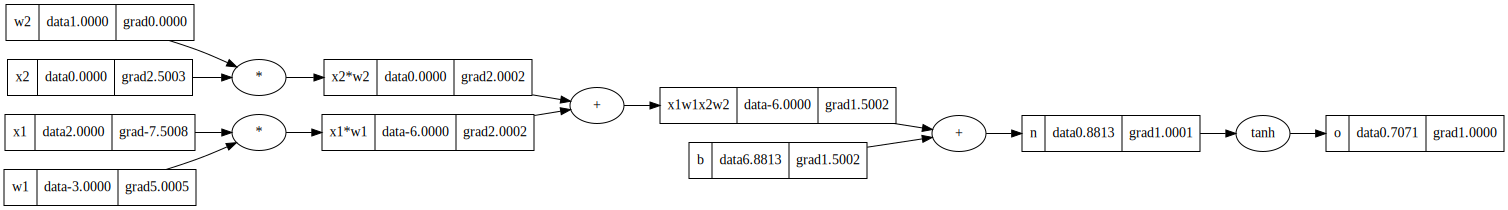

In [16]:
draw_dot(o)

In [15]:
o.backward()

In [8]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1w1.grad = 0.5
x2w2.grad = 0.5
x1w1x2w2.grad =0.5
b.grad = 0.5
n.grad = 0.5

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

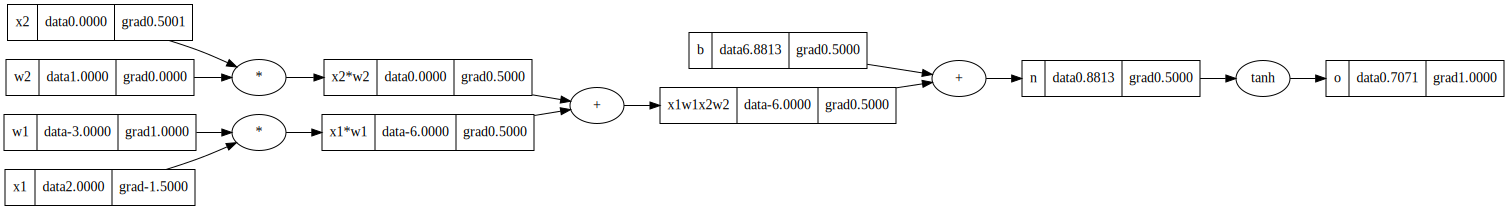

In [9]:
draw_dot(o)

In [29]:
# implementing perceptron with activation function tanh

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2+b; 
n.label = 'n'

o = n.tanh(); o.label = 'o'
o.backward()


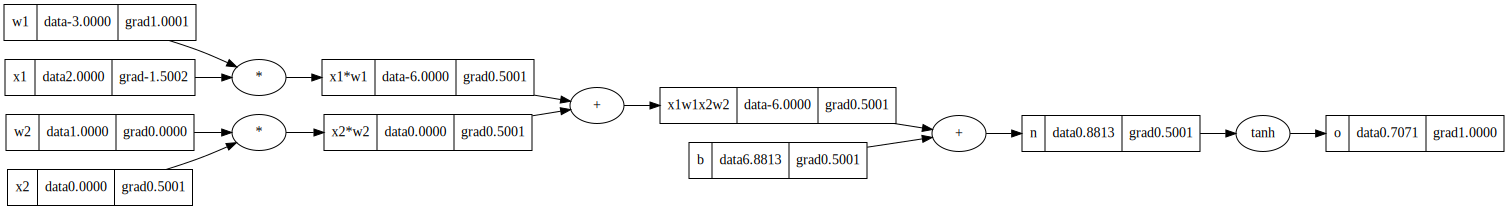

In [30]:
draw_dot(o)

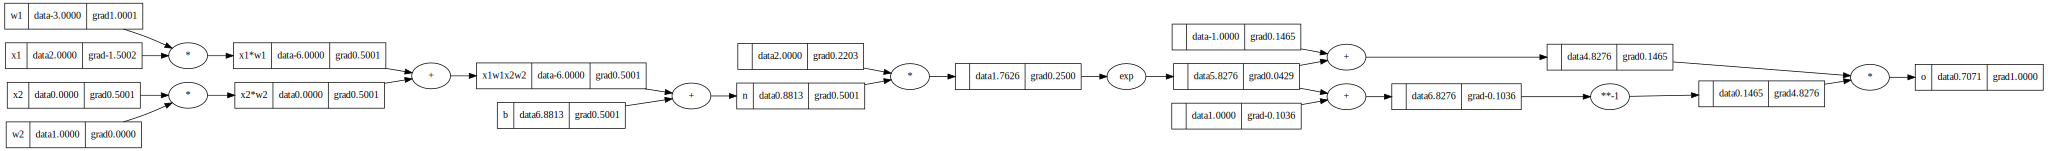

In [ ]:
# implementing perceptron with activation function tanh

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2+b; 
n.label = 'n'

e = (2*n).exp();
o = (e-1)/(e+1);
o.label = 'o'
o.backward()
draw_dot(o)


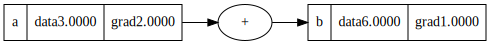

In [17]:
a = Value(3.0, label = 'a')
b = a+a;
b.label = 'b'
b.backward()
draw_dot(b)

In [28]:
a = Value(2.0)
b = Value(4.0)
a-b

Value(data=-2.0)

In [33]:
import torch

In [36]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True; # cast to double since python uses float64 and pytorch uses float32
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True; # since these are leaf nodes, pytorch assumes they dont require gradient, by default set to false due to efficiency reason
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True;
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True;

b = torch.Tensor([6.8813]).double(); b_requires_grad = True;
n=x1*w1 + x2*w2 + b;
o = torch.tanh(n);


print(o.data.item())
o.backward()


print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7070699720278941
---
x2 0.5000520546564731
w2 0.0
x1 -1.5001561639694192
w1 1.0001041093129461


In [37]:
o.item()

0.7070699720278941

using tensors in torch is much efficient due to parallel computing possible